In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy.ndimage import uniform_filter


PROJECT = Path(r"Z:\Projects\monsoon-postprocessing")

COMPARISON_FILE = (
    PROJECT
    / "data"
    / "processed"
    / "gefs_imerg_comparison_20180702.nc"
)

METRICS_FILE = (
    PROJECT
    / "data"
    / "processed"
    / "verification_metrics_20180702.csv"
)


# Load into memory and close the NetCDF file immediately.
with xr.open_dataset(COMPARISON_FILE) as ds:
    comparison_ds = ds.load()

forecast = comparison_ds["gefs_rainfall"]
observed = comparison_ds["imerg_rainfall"]

print(comparison_ds)

<xarray.Dataset> Size: 314kB
Dimensions:         (latitude: 129, longitude: 121)
Coordinates:
  * latitude        (latitude) float64 1kB 6.0 6.25 6.5 6.75 ... 37.5 37.75 38.0
  * longitude       (longitude) float64 968B 68.0 68.25 68.5 ... 97.5 97.75 98.0
    number          int64 8B 0
    time            datetime64[ns] 8B 2018-07-01
    surface         float64 8B 0.0
Data variables:
    gefs_rainfall   (latitude, longitude) float32 62kB 2.97 1.58 ... 9.61 11.06
    imerg_rainfall  (latitude, longitude) float64 125kB nan nan nan ... nan nan
    forecast_error  (latitude, longitude) float64 125kB nan nan nan ... nan nan
Attributes:
    date:                     2018-07-02
    forecast_initialization:  2018-07-01 00 UTC
    forecast_lead_period:     24-48 hours
    observation_source:       NASA GPM IMERG Final
    error_definition:         GEFS minus IMERG


In [2]:
forecast_values = forecast.values
observed_values = observed.values

# Use only cells where both forecast and observation are available.
valid_mask = (
    np.isfinite(forecast_values)
    & np.isfinite(observed_values)
)

forecast_valid = forecast_values[valid_mask]
observed_valid = observed_values[valid_mask]

errors = forecast_valid - observed_valid

print("Valid grid cells:", errors.size)

Valid grid cells: 15113


In [3]:
rmse = np.sqrt(np.mean(errors ** 2))
mae = np.mean(np.abs(errors))
bias = np.mean(errors)

if (
    np.std(forecast_valid) > 0
    and np.std(observed_valid) > 0
):
    correlation = np.corrcoef(
        forecast_valid,
        observed_valid
    )[0, 1]
else:
    correlation = np.nan


print(f"RMSE: {rmse:.2f} mm")
print(f"MAE: {mae:.2f} mm")
print(f"Mean bias: {bias:.2f} mm")
print(f"Spatial correlation: {correlation:.3f}")

RMSE: 21.38 mm
MAE: 11.62 mm
Mean bias: 5.95 mm
Spatial correlation: 0.481


In [5]:
def calculate_categorical_metrics(
    forecast_values,
    observed_values,
    threshold
):
    """Calculate rainfall-event verification metrics."""

    forecast_event = forecast_values >= threshold
    observed_event = observed_values >= threshold

    hits = np.sum(forecast_event & observed_event)
    misses = np.sum(~forecast_event & observed_event)
    false_alarms = np.sum(forecast_event & ~observed_event)
    correct_negatives = np.sum(~forecast_event & ~observed_event)

    total = (
        hits
        + misses
        + false_alarms
        + correct_negatives
    )

    csi_denominator = hits + misses + false_alarms
    pod_denominator = hits + misses
    far_denominator = hits + false_alarms

    csi = (
        hits / csi_denominator
        if csi_denominator > 0
        else np.nan
    )

    pod = (
        hits / pod_denominator
        if pod_denominator > 0
        else np.nan
    )

    far = (
        false_alarms / far_denominator
        if far_denominator > 0
        else np.nan
    )

    # Expected hits produced by random chance.
    random_hits = (
        ((hits + misses) * (hits + false_alarms)) / total
        if total > 0
        else np.nan
    )

    ets_denominator = (
        hits
        + misses
        + false_alarms
        - random_hits
    )

    ets = (
        (hits - random_hits) / ets_denominator
        if ets_denominator > 0
        else np.nan
    )

    return {
        "threshold_mm": threshold,
        "hits": int(hits),
        "misses": int(misses),
        "false_alarms": int(false_alarms),
        "correct_negatives": int(correct_negatives),
        "CSI": csi,
        "POD": pod,
        "FAR": far,
        "ETS": ets
    }

In [6]:
rainfall_thresholds = [
    64.5,
    115.6
]

categorical_results = []

for threshold in rainfall_thresholds:
    result = calculate_categorical_metrics(
        forecast_valid,
        observed_valid,
        threshold
    )

    categorical_results.append(result)


categorical_df = pd.DataFrame(
    categorical_results
)

categorical_df

,threshold_mm,hits,misses,false_alarms,correct_negatives,CSI,POD,FAR,ETS
0,64.5,93,176,369,14475,0.145768,0.345725,0.798701,0.134614
1,115.6,6,14,122,14971,0.042254,0.300000,0.953125,0.041110


In [7]:
for result in categorical_results:
    print(
        f"\nThreshold: {result['threshold_mm']} mm"
    )
    print("Hits:", result["hits"])
    print("Misses:", result["misses"])
    print("False alarms:", result["false_alarms"])
    print(f"CSI: {result['CSI']:.3f}")
    print(f"POD: {result['POD']:.3f}")
    print(f"FAR: {result['FAR']:.3f}")
    print(f"ETS: {result['ETS']:.3f}")


Threshold: 64.5 mm
Hits: 93
Misses: 176
False alarms: 369
CSI: 0.146
POD: 0.346
FAR: 0.799
ETS: 0.135

Threshold: 115.6 mm
Hits: 6
Misses: 14
False alarms: 122
CSI: 0.042
POD: 0.300
FAR: 0.953
ETS: 0.041


In [8]:
def calculate_fss(
    forecast_grid,
    observed_grid,
    threshold,
    neighborhood_size
):
    """Calculate Fractions Skill Score for one threshold and scale."""

    forecast_binary = (
        forecast_grid >= threshold
    ).astype(float)

    observed_binary = (
        observed_grid >= threshold
    ).astype(float)

    # Calculate event fractions inside each neighbourhood.
    forecast_fraction = uniform_filter(
        forecast_binary,
        size=neighborhood_size,
        mode="constant",
        cval=0
    )

    observed_fraction = uniform_filter(
        observed_binary,
        size=neighborhood_size,
        mode="constant",
        cval=0
    )

    numerator = np.sum(
        (forecast_fraction - observed_fraction) ** 2
    )

    denominator = np.sum(
        forecast_fraction ** 2
        + observed_fraction ** 2
    )

    if denominator == 0:
        return np.nan

    return 1 - (numerator / denominator)

In [9]:
neighborhood_sizes = [
    1,
    3,
    5,
    9
]

fss_results = []

for threshold in rainfall_thresholds:
    for size in neighborhood_sizes:
        fss = calculate_fss(
            forecast_values,
            observed_values,
            threshold,
            size
        )

        fss_results.append({
            "threshold_mm": threshold,
            "neighborhood_cells": size,
            "approximate_scale_km": size * 25,
            "FSS": fss
        })


fss_df = pd.DataFrame(fss_results)
fss_df

,threshold_mm,neighborhood_cells,approximate_scale_km,FSS
0,64.5,1,25,0.254098
1,64.5,3,75,0.399504
2,64.5,5,125,0.499335
3,64.5,9,225,0.583442
4,115.6,1,25,0.081081
5,115.6,3,75,0.160947
6,115.6,5,125,0.217050
7,115.6,9,225,0.260391


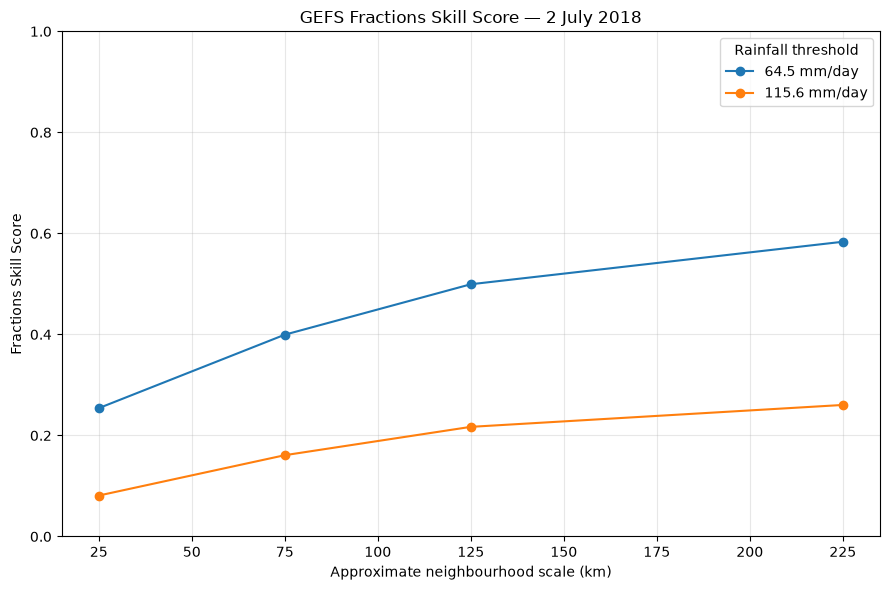

In [10]:
plt.figure(figsize=(9, 6))

for threshold in rainfall_thresholds:
    threshold_data = fss_df[
        fss_df["threshold_mm"] == threshold
    ]

    plt.plot(
        threshold_data["approximate_scale_km"],
        threshold_data["FSS"],
        marker="o",
        label=f"{threshold} mm/day"
    )

plt.xlabel("Approximate neighbourhood scale (km)")
plt.ylabel("Fractions Skill Score")
plt.title("GEFS Fractions Skill Score — 2 July 2018")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend(title="Rainfall threshold")
plt.tight_layout()
plt.show()

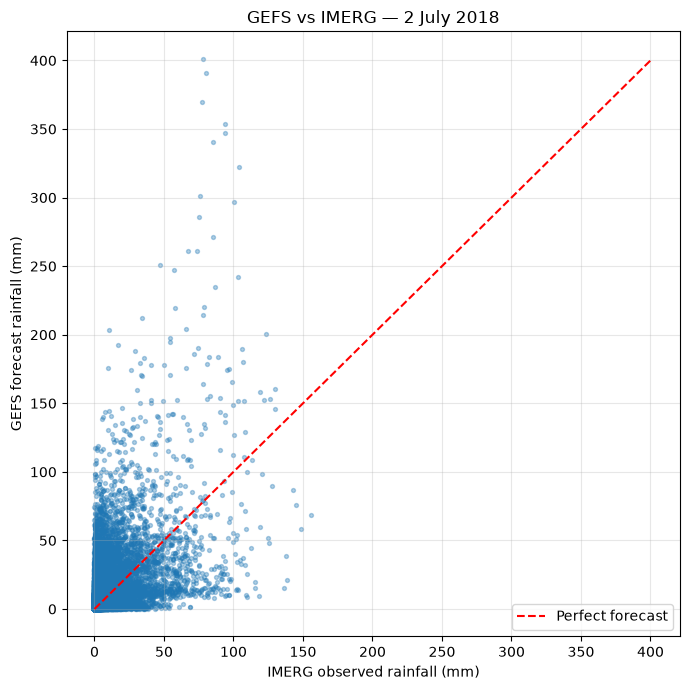

In [11]:
plt.figure(figsize=(7, 7))

plt.scatter(
    observed_valid,
    forecast_valid,
    s=8,
    alpha=0.35
)

maximum_value = max(
    observed_valid.max(),
    forecast_valid.max()
)

# The diagonal represents a perfect forecast.
plt.plot(
    [0, maximum_value],
    [0, maximum_value],
    color="red",
    linestyle="--",
    label="Perfect forecast"
)

plt.xlabel("IMERG observed rainfall (mm)")
plt.ylabel("GEFS forecast rainfall (mm)")
plt.title("GEFS vs IMERG — 2 July 2018")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
metric_rows = [
    {
        "metric": "RMSE",
        "threshold_mm": np.nan,
        "neighborhood_cells": np.nan,
        "value": rmse
    },
    {
        "metric": "MAE",
        "threshold_mm": np.nan,
        "neighborhood_cells": np.nan,
        "value": mae
    },
    {
        "metric": "Mean Bias",
        "threshold_mm": np.nan,
        "neighborhood_cells": np.nan,
        "value": bias
    },
    {
        "metric": "Spatial Correlation",
        "threshold_mm": np.nan,
        "neighborhood_cells": np.nan,
        "value": correlation
    }
]


for result in categorical_results:
    for metric in ["CSI", "POD", "FAR", "ETS"]:
        metric_rows.append({
            "metric": metric,
            "threshold_mm": result["threshold_mm"],
            "neighborhood_cells": np.nan,
            "value": result[metric]
        })


for result in fss_results:
    metric_rows.append({
        "metric": "FSS",
        "threshold_mm": result["threshold_mm"],
        "neighborhood_cells": result[
            "neighborhood_cells"
        ],
        "value": result["FSS"]
    })


metrics_df = pd.DataFrame(metric_rows)

metrics_df.to_csv(
    METRICS_FILE,
    index=False
)

print("Saved:", METRICS_FILE.exists())
print("Location:", METRICS_FILE)

metrics_df

Saved: True
Location: Z:\Projects\monsoon-postprocessing\data\processed\verification_metrics_20180702.csv


,metric,threshold_mm,neighborhood_cells,value
0,RMSE,NaN,NaN,21.378555
1,MAE,NaN,NaN,11.616257
2,Mean Bias,NaN,NaN,5.954987
3,Spatial Correlation,NaN,NaN,0.481257
4,CSI,64.5,NaN,0.145768
5,POD,64.5,NaN,0.345725
6,FAR,64.5,NaN,0.798701
7,ETS,64.5,NaN,0.134614
8,CSI,115.6,NaN,0.042254
9,POD,115.6,NaN,0.300000
